In [1]:
# Import Libraries

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import tensorflow as tf

2025-09-01 22:46:46.826190: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756747006.847987 1681227 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756747006.855334 1681227 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756747006.880354 1681227 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1756747006.880397 1681227 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1756747006.880402 1681227 computation_placer.cc:177] computation placer alr

In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    # Restrict TensorFlow to only allocate 70% of memory on the first GPU
    def get_gpu_memory():
        import subprocess
        command = "nvidia-smi --query-gpu=memory.free --format=csv"
        memory_free_info = subprocess.check_output(command.split()).decode('ascii').split('\n')[:-1][1:]
        memory_free_values = [int(x.split()[0]) for i, x in enumerate(memory_free_info)]
        return memory_free_values
    
    mem = get_gpu_memory()
    mem = int(0.7*mem[0])
    
    try:
        tf.config.experimental.set_virtual_device_configuration(
            gpus[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=mem)])
        print(f"Allocated a tensorflow object 70% ({mem}MB) of memory for this standalone notebook.")
    except:
        print("Failed to allocate GPU memory")

Allocated a tensorflow object 70% (2774MB) of memory for this standalone notebook.


In [3]:
# read data

df = pd.read_csv("Data_csv.csv")
print(df.head())
print("Shape:",df.shape)

     Pressure  Temperature    x1        y1
0  336.647251       333.15  0.92  0.966363
1  338.205898       333.15  0.93  0.970736
2  339.836648       333.15  0.94  0.975065
3  341.539863       333.15  0.95  0.979348
4  343.315926       333.15  0.96  0.983582
Shape: (320, 4)


In [4]:
# Our Data contains 4 parameters for Ethanol - Water Binary Azeotropic Blend:
# Pressure, Temperature, x1 for Ethanol, y1 for Ethanol

# dividing data into train, val, test split

Xtrain, Xtest, ytrain, ytest = train_test_split(df.drop(["y1"], axis=1), df['y1'], shuffle=True, train_size=0.8)
# Xtest, Xval, ytest, yval = train_test_split(Xtest, ytest, train_size=0.5)

In [5]:
# Min Max Scaling for value clipping

mmx = MinMaxScaler()

Xtrainmmx = mmx.fit_transform(Xtrain)
Xtestmmx = mmx.transform(Xtest)
# Xvalmmx = mmx.transform(Xval)

In [6]:
# fit a ridge regressor

print("Fitting Ridge Regressor:")
rr = Ridge()
rr.fit(Xtrainmmx, ytrain.values)

Fitting Ridge Regressor:


Ridge()

In [7]:
pred = rr.predict(Xtestmmx)

print("R2Score of Ridge: ", r2_score(pred, ytest.values))
print("MAE of Ridge: ", mean_absolute_error(pred, ytest.values))
print("RMSE of Ridge: ", root_mean_squared_error(pred, ytest.values))

R2Score of Ridge:  0.9982528505310561
MAE of Ridge:  0.0003400218709483458
RMSE of Ridge:  0.0004074165956204983


In [8]:
# # Testing the search space for optimal beta and beta 2

# baseb1 = 0.729
# baseb2 = 0.612
# baser2 = 0.9997851040402369 
# basel2 = 0.005

# for k in range(600,750):
#     ann = tf.keras.Sequential([
#     tf.keras.layers.Input(shape=(3,)),
#     tf.keras.layers.Dense(20, activation='tanh', activity_regularizer=tf.keras.regularizers.L2(0.005)),
#     tf.keras.layers.Dense(30, activation='softmax'),
#     tf.keras.layers.Dense(1, activation='linear')
#     ])

#     ann.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, beta_1 = 0.729, beta_2=k/1000), loss=tf.keras.losses.MAE, metrics=['accuracy'])
    
#     ann.fit(Xtrainmmx, ytrain, epochs=100, verbose=0)
    
#     b = r2_score(ann.predict(Xtestmmx), ytest)
    
#     if b>baser2:
#         baser2 = b
#         baseb2 = k/1000
#         print(f"R2: {baser2} on Beta1: {baseb1} Beta2: {baseb2} L2: {basel2}")

# print(f"Final\nR2: {baser2} on Beta1: {baseb1} Beta2: {baseb2} L2: {basel2}")

In [9]:
# ANN model

ann = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(20, activation='tanh', activity_regularizer=tf.keras.regularizers.L2(0.005)),
    tf.keras.layers.Dense(30, activation='softmax'),
    tf.keras.layers.Dense(1, activation='linear')
])

ann.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, beta_1=0.729, beta_2=0.612), loss=tf.keras.losses.MAE, metrics=['mean_squared_error', 'mean_absolute_error', 'r2_score']) # optimal values from searching

I0000 00:00:1756747014.270529 1681227 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2774 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [10]:
print(ann.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           630 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 741 (2.89 KB)

 Trainable params: 741 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

None


In [11]:
hist = ann.fit(Xtrainmmx, ytrain, epochs=200)

Epoch 1/200


I0000 00:00:1756747015.918298 1681328 service.cc:152] XLA service 0x700db400cfb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756747015.918340 1681328 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-09-01 22:46:55.940385: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1756747016.055542 1681328 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/8 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - loss: 1.1970 - mean_absolute_error: 0.9596 - mean_squared_error: 0.9211 - r2_score: -10363.6738

I0000 00:00:1756747017.080109 1681328 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 1.1639 - mean_absolute_error: 0.9561 - mean_squared_error: 0.9144 - r2_score: -10088.5791
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1136 - mean_absolute_error: 0.9339 - mean_squared_error: 0.8725 - r2_score: -9288.2881 
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0781 - mean_absolute_error: 0.9123 - mean_squared_error: 0.8325 - r2_score: -9475.6689 
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0442 - mean_absolute_error: 0.8897 - mean_squared_error: 0.7919 - r2_score: -8423.0361 
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0080 - mean_absolute_error: 0.8708 - mean_squared_error: 0.7587 - r2_score: -8226.3467 
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9771 - mean_absolute_error: 0.8502 - mean_squared_error: 0.7234 - r2_score: -8161.0034 
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9439 - mean_absolute_error: 0.8295 - mean_squared_error: 0.6886 - r2_s

In [12]:
pred = ann.predict(Xtestmmx)

print("R2 Score: ",r2_score(pred, ytest))
print("MAE: ", mean_absolute_error(pred, ytest))
print("RMSE: ", root_mean_squared_error(pred, ytest))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step 
R2 Score:  0.9992532933912667
MAE:  0.00021169877464102121
RMSE:  0.0002808772539029091


In [13]:
ann.save("ANN.keras")

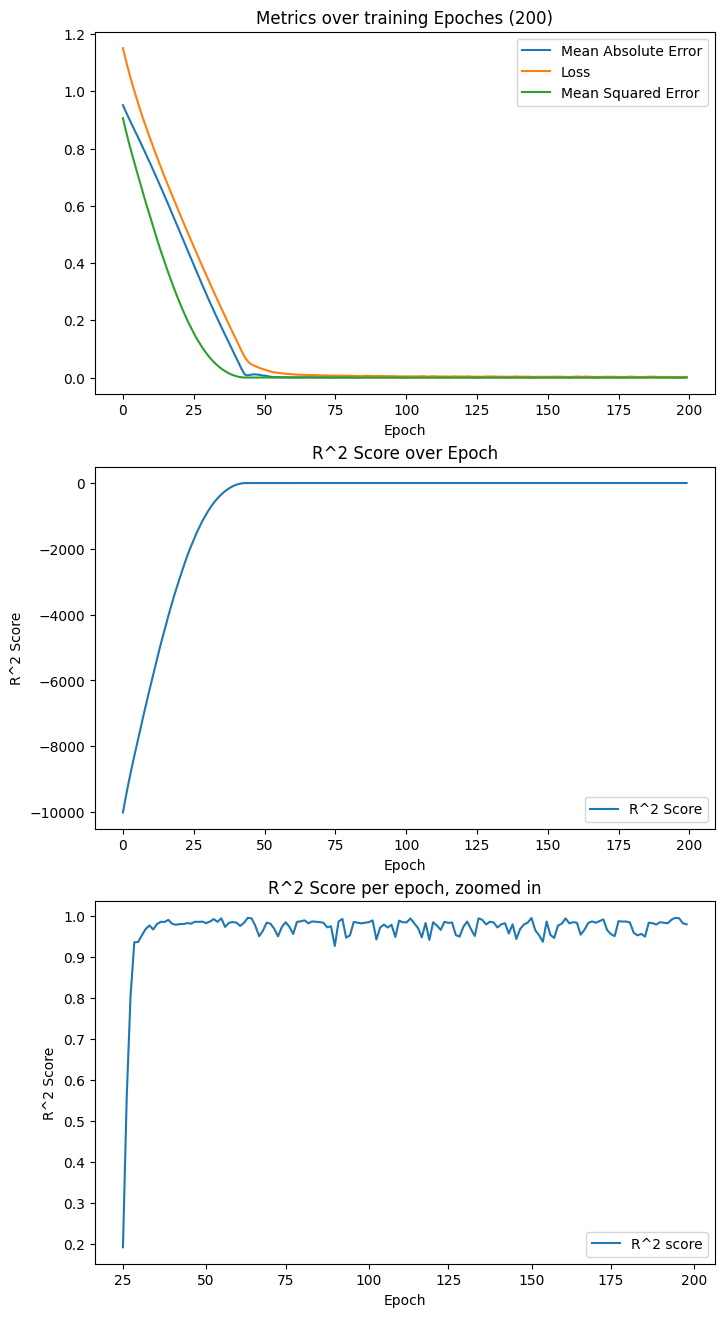

In [14]:
fig = plt.figure(figsize=(8,16))
plt.subplot(3,1,1)
plt.plot(hist.history['mean_absolute_error'])
plt.plot(hist.history['loss'])
plt.plot(hist.history['mean_squared_error'])
plt.legend(['Mean Absolute Error','Loss','Mean Squared Error'])
plt.title("Metrics over training Epoches (200)")
plt.xlabel("Epoch")

plt.subplot(3,1,2)
plt.plot(hist.history['r2_score'])
plt.title('R^2 Score over Epoch')
plt.legend(['R^2 Score'])
plt.xlabel('Epoch')
plt.ylabel("R^2 Score")

plt.subplot(3,1,3)
plt.plot(hist.history['r2_score'][50:])
ax = plt.gca()
ax.set_xticks([0,22,43,65,86,108,129,151])
ax.set_xticklabels([25, 50, 75, 100, 125, 150, 175, 200])
plt.title("R^2 Score per epoch, zoomed in")
plt.xlabel('Epoch')
plt.ylabel('R^2 Score')
plt.legend(['R^2 score'])
plt.savefig("Loss.png", dpi=600)
plt.show()

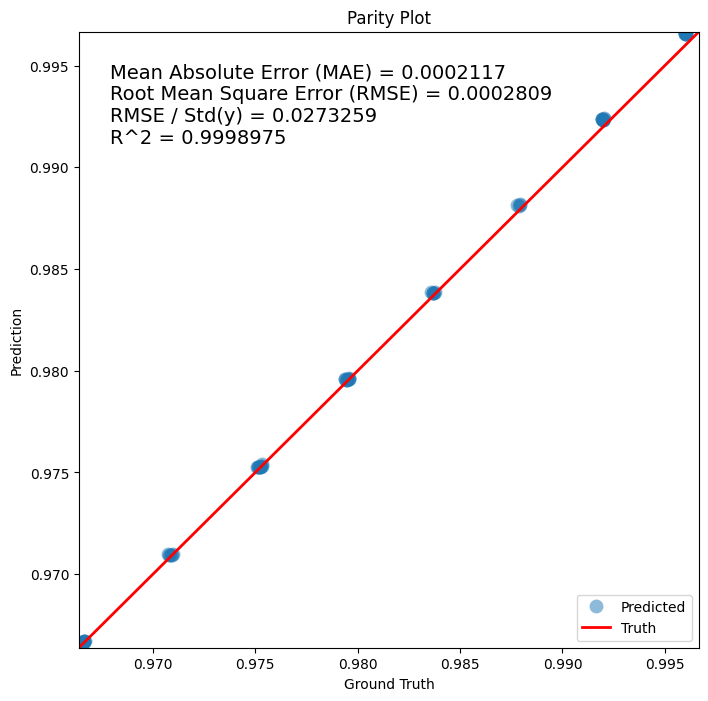

In [15]:
# parity plot

fig = plt.figure(figsize=(8,8))
x = np.squeeze(ytest.values)
y = np.squeeze(pred)
bounds = (min(x.min(), y.min()) - int(0.1 * y.min()), max(x.max(), y.max())+ int(0.1 * y.max()))
ax = plt.gca()
ax.set_xlim(bounds)
ax.set_ylim(bounds)

plt.plot(x,y,"o", alpha=0.5 ,ms=10, markeredgewidth=0.0)

ax.plot([0, 1], [0, 1], "r-",lw=2 ,transform=ax.transAxes)

# Calculate Statistics of the Parity Plot 
mean_abs_err = np.mean(np.abs(x-y))
rmse = np.sqrt(np.mean((x-y)**2))
rmse_std = rmse / np.std(y)
z = np.polyfit(x,y, 1)
y_hat = np.poly1d(z)(x)
text = f"Mean Absolute Error (MAE) = {mean_abs_err:0.7f} \nRoot Mean Square Error (RMSE) = {rmse:0.7f} \nRMSE / Std(y) = {rmse_std :0.7f} \nR^2 = {r2_score(y,y_hat):0.7f}"

plt.gca().text(0.05, 0.95, text,transform=plt.gca().transAxes, fontsize=14, verticalalignment='top')

# Title and labels 
plt.title("Parity Plot")
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.legend(['Predicted', 'Truth'])
plt.savefig("Parity Plot.png", dpi=300)
plt.show()